# Combined Logistic Model Comparison

This notebook runs the three classifier-only workflows in one place:

1. **Weather only**
2. **State + history only**
3. **Full model** (state + history + weather)

For each workflow, it:
- trains the full classifier
- ranks features by importance
- retrains on the top **N** features
- evaluates on the held-out 2025 test set
- stores predictions for shared comparison visuals


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    f1_score
)

sns.set_style("whitegrid")


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

# -----------------------------
# Configuration
# -----------------------------
TOP_N = 10
RANDOM_STATE = 123
USE_CUDA = True  # set False if your XGBoost build does not support CUDA

DEVICE = "cuda" if USE_CUDA else "cpu"

# -----------------------------
# Load data
# -----------------------------
csv_candidates = [
    "ml_panel_noaa_x_fda_recalls_x_cost.csv",
    "ml_panel_noaa_x_fda_recalls_x_cost(1).csv"
]

df = None
for fp in csv_candidates:
    try:
        df = pd.read_csv(fp)
        print(f"Loaded: {fp}")
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError("Could not find the expected CSV file.")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["state_abbr", "date"]).reset_index(drop=True)

target = "log_pathogen_cost_index"
raw_target = "pathogen_weighted_cost_index"

# Event indicator
df["event_flag"] = (df[raw_target] > 0).astype(int)

# -----------------------------
# Feature engineering
# -----------------------------
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["temp_roll12"] = df.groupby("state_abbr")["temp_f"].transform(
    lambda x: x.rolling(12, min_periods=3).mean()
)
df["pcpn_roll12"] = df.groupby("state_abbr")["pcpn_in"].transform(
    lambda x: x.rolling(12, min_periods=3).mean()
)

df["temp_dev"] = df["temp_f"] - df["temp_roll12"]
df["pcpn_dev"] = df["pcpn_in"] - df["pcpn_roll12"]

df["temp_x_pcpn"] = df["temp_f"] * df["pcpn_in"]
df["temp_dev_x_pcpn_dev"] = df["temp_dev"] * df["pcpn_dev"]

df["event_lag1"] = df.groupby("state_abbr")["event_flag"].shift(1)
df["event_roll3"] = (
    df.groupby("state_abbr")["event_flag"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

if "temp_anom" in df.columns and "pcpn_anom" in df.columns:
    df["temp_anom_x_pcpn_anom"] = df["temp_anom"] * df["pcpn_anom"]

# -----------------------------
# Train/test split
# -----------------------------
train_df = df[df["year"].between(2012, 2024)].copy()
test_df  = df[df["year"] >= 2025].copy()

# -----------------------------
# Train-only state features
# -----------------------------
state_baseline = train_df.groupby("state_abbr")[target].mean()
global_baseline = train_df[target].mean()

train_df["state_baseline_cost"] = train_df["state_abbr"].map(state_baseline).fillna(global_baseline)
test_df["state_baseline_cost"]  = test_df["state_abbr"].map(state_baseline).fillna(global_baseline)

state_event_rate = train_df.groupby("state_abbr")["event_flag"].mean()
global_event_rate = train_df["event_flag"].mean()

train_df["state_event_rate"] = train_df["state_abbr"].map(state_event_rate).fillna(global_event_rate)
test_df["state_event_rate"]  = test_df["state_abbr"].map(state_event_rate).fillna(global_event_rate)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

y_train_cls = train_df["event_flag"]
y_test_cls = test_df["event_flag"]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train event rate:", y_train_cls.mean())
print("Test event rate:", y_test_cls.mean())


Loaded: ml_panel_noaa_x_fda_recalls_x_cost.csv
Train rows: 9947
Test rows: 1176
Train event rate: 0.11561274756207902
Test event rate: 0.06717687074829932


In [3]:

# -----------------------------
# Feature sets
# -----------------------------
weather_feature_cols = [
    "month",
    "temp_f",
    "pcpn_in",
    "temp_anom",
    "pcpn_anom",
    "temp_f_lag1",
    "pcpn_in_lag1",
    "temp_f_roll3",
    "pcpn_in_roll3",
    "month_sin",
    "month_cos",
    "temp_roll12",
    "pcpn_roll12",
    "temp_dev",
    "pcpn_dev",
    "temp_x_pcpn",
    "temp_dev_x_pcpn_dev",
    "temp_anom_x_pcpn_anom"
]

state_history_feature_cols = [
    "state_baseline_cost",
    "state_event_rate",
    "event_lag1",
    "event_roll3",
    "month",
    "month_sin",
    "month_cos"
]

full_feature_cols = [
    "month",
    "temp_f",
    "pcpn_in",
    "temp_anom",
    "pcpn_anom",
    "temp_f_lag1",
    "pcpn_in_lag1",
    "temp_f_roll3",
    "pcpn_in_roll3",
    "month_sin",
    "month_cos",
    "temp_roll12",
    "pcpn_roll12",
    "temp_dev",
    "pcpn_dev",
    "temp_x_pcpn",
    "temp_dev_x_pcpn_dev",
    "event_lag1",
    "event_roll3",
    "temp_anom_x_pcpn_anom",
    "state_baseline_cost",
    "state_event_rate"
]

param_grid = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

def fit_topn_classifier(model_name, feature_cols, top_n=10):
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]

    pos = y_train_cls.sum()
    neg = len(y_train_cls) - pos
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device=DEVICE,
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight
    )

    tscv = TimeSeriesSplit(n_splits=6)

    clf_search = RandomizedSearchCV(
        estimator=clf,
        param_distributions=param_grid,
        n_iter=30,
        scoring="average_precision",
        cv=tscv,
        verbose=1,
        n_jobs=1,
        random_state=RANDOM_STATE,
        error_score="raise"
    )

    clf_search.fit(X_train, y_train_cls)
    best_clf = clf_search.best_estimator_

    full_probs = best_clf.predict_proba(X_test)[:, 1]
    full_auc = roc_auc_score(y_test_cls, full_probs)
    full_ap = average_precision_score(y_test_cls, full_probs)

    importances = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    top_features = importances.head(min(top_n, len(importances))).index.tolist()

    X_train_top = X_train[top_features]
    X_test_top = X_test[top_features]

    clf_top = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device=DEVICE,
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        **clf_search.best_params_
    )
    clf_top.fit(X_train_top, y_train_cls)

    top_probs = clf_top.predict_proba(X_test_top)[:, 1]
    top_auc = roc_auc_score(y_test_cls, top_probs)
    top_ap = average_precision_score(y_test_cls, top_probs)

    precision, recall, thresholds = precision_recall_curve(y_test_cls, top_probs)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    y_pred_best = (top_probs >= best_threshold).astype(int)
    report = classification_report(y_test_cls, y_pred_best, output_dict=True)
    cm = confusion_matrix(y_test_cls, y_pred_best)

    return {
        "model_name": model_name,
        "feature_cols": feature_cols,
        "best_params": clf_search.best_params_,
        "full_auc": full_auc,
        "full_ap": full_ap,
        "top_features": top_features,
        "top_auc": top_auc,
        "top_ap": top_ap,
        "top_probs": top_probs,
        "precision_curve": precision,
        "recall_curve": recall,
        "thresholds": thresholds,
        "best_threshold": best_threshold,
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "support": report["1"]["support"],
        "accuracy": report["accuracy"],
        "confusion_matrix": cm,
        "feature_importances_full": importances,
        "feature_importances_top": pd.Series(clf_top.feature_importances_, index=top_features).sort_values(ascending=False),
        "clf_top": clf_top,
        "X_train_top": X_train_top,
    }


In [4]:

# -----------------------------
# Run the three logistic workflows
# -----------------------------
weather_results = fit_topn_classifier("Weather Only", weather_feature_cols, top_n=TOP_N)
state_hist_results = fit_topn_classifier("State + History", state_history_feature_cols, top_n=TOP_N)
full_results = fit_topn_classifier("Full Model", full_feature_cols, top_n=TOP_N)

all_results = [weather_results, state_hist_results, full_results]

for res in all_results:
    print("\n" + "="*60)
    print(res["model_name"])
    print("Best full-model params:", res["best_params"])
    print("Feature count:", len(res["feature_cols"]))
    print("Full-model AUC:", round(res["full_auc"], 4))
    print("Full-model AP:", round(res["full_ap"], 4))
    print("Top features:", res["top_features"])
    print("Top-N AUC:", round(res["top_auc"], 4))
    print("Top-N AP:", round(res["top_ap"], 4))
    print("Best threshold:", round(res["best_threshold"], 4))
    print("Precision:", round(res["precision"], 4))
    print("Recall:", round(res["recall"], 4))
    print("F1:", round(res["f1"], 4))


Fitting 6 folds for each of 30 candidates, totalling 180 fits


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\xgboost\core.py:751: UserWarning: [18:31:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fitting 6 folds for each of 30 candidates, totalling 180 fits
Fitting 6 folds for each of 30 candidates, totalling 180 fits

Weather Only
Best full-model params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 1200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Feature count: 18
Full-model AUC: 0.8551
Full-model AP: 0.34
Top features: ['pcpn_roll12', 'temp_roll12', 'temp_dev', 'temp_f_roll3', 'pcpn_in_roll3', 'temp_f_lag1', 'pcpn_anom', 'temp_f', 'month', 'temp_anom']
Top-N AUC: 0.842
Top-N AP: 0.3441
Best threshold: 0.6797
Precision: 0.5091
Recall: 0.3544
F1: 0.4179

State + History
Best full-model params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 1200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 1.0}
Feature count: 7
Full-model AUC: 0.9888
Full-model AP: 0.8534
Top features: ['event_roll3', 'event_lag1', 'month_cos', 'month', 'stat

In [5]:

# -----------------------------
# Comparison table
# -----------------------------
comparison_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Full AUC": r["full_auc"],
        "Full AP": r["full_ap"],
        "Top-N AUC": r["top_auc"],
        "Top-N AP": r["top_ap"],
        "Best Threshold": r["best_threshold"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
    }
    for r in all_results
])

comparison_display = comparison_df.copy()
num_cols = comparison_display.select_dtypes(include=["number"]).columns
comparison_display[num_cols] = comparison_display[num_cols].round(3)
comparison_display


,Model,Full AUC,Full AP,Top-N AUC,Top-N AP,Best Threshold,Precision,Recall,F1
0,Weather Only,0.855,0.340,0.842,0.344,0.680,0.509,0.354,0.418
1,State + History,0.989,0.853,0.989,0.853,0.868,0.722,0.886,0.795
2,Full Model,0.985,0.828,0.989,0.858,0.873,0.713,0.911,0.800


In [14]:

# -----------------------------
# Comparison table
# -----------------------------
comparison_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Full AUC": r["full_auc"],
        "Full AP": r["full_ap"],
        "Top-N AUC": r["top_auc"],
        "Top-N AP": r["top_ap"],
        "Best Threshold": r["best_threshold"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
    }
    for r in all_results
])

comparison_display = comparison_df.copy()
num_cols = comparison_display.select_dtypes(include=["number"]).columns
comparison_display[num_cols] = comparison_display[num_cols].round(3)
comparison_display

,Model,Full AUC,Full AP,Top-N AUC,Top-N AP,Best Threshold,Precision,Recall,F1
0,Weather Only,0.855,0.340,0.842,0.344,0.680,0.509,0.354,0.418
1,State + History,0.989,0.853,0.989,0.853,0.868,0.722,0.886,0.795
2,Full Model,0.985,0.828,0.989,0.858,0.873,0.713,0.911,0.800


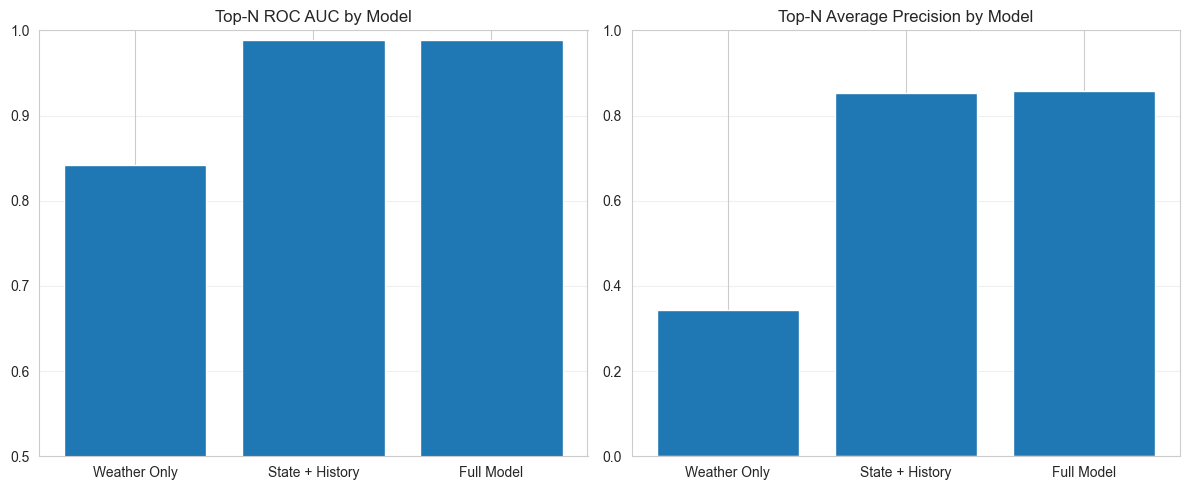

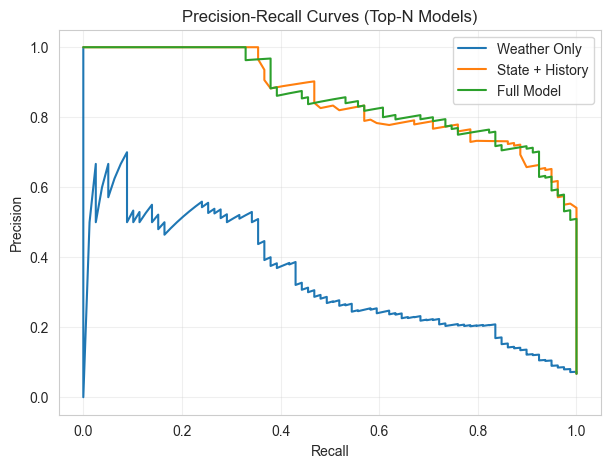

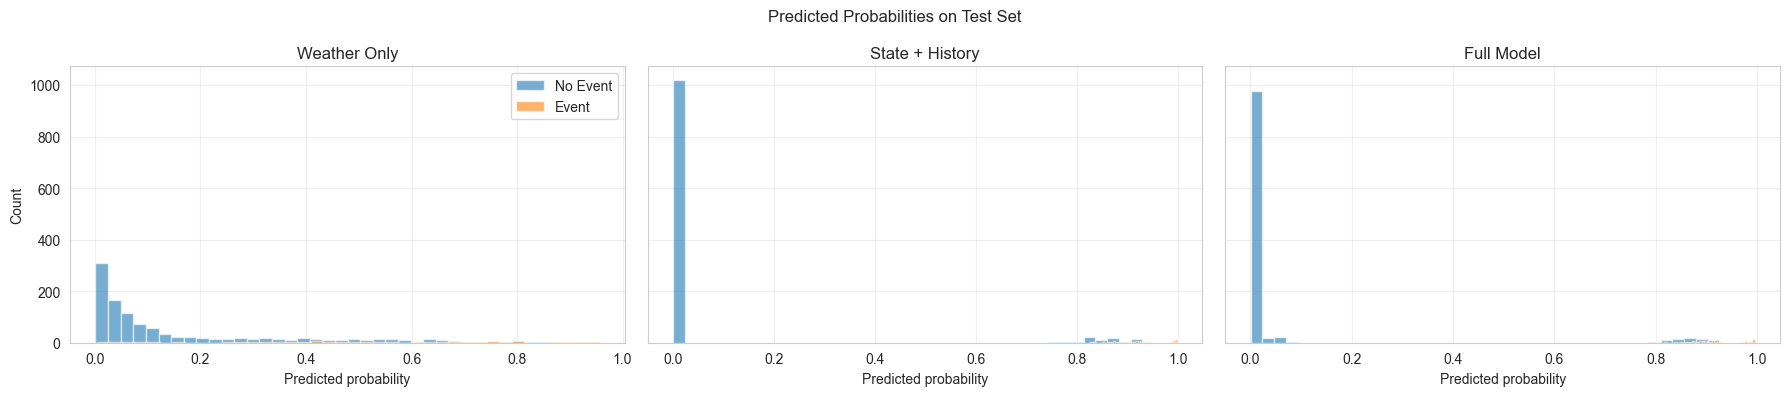

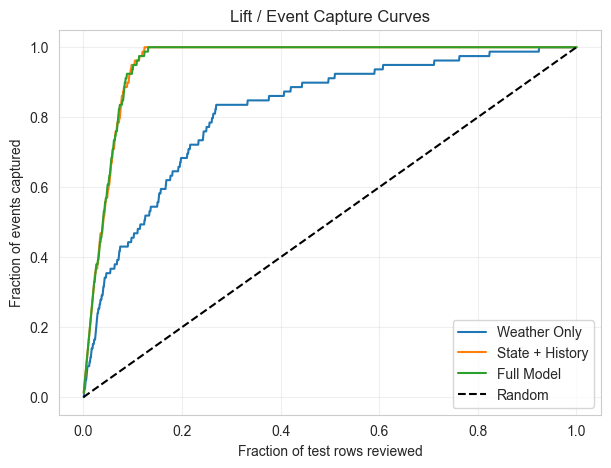

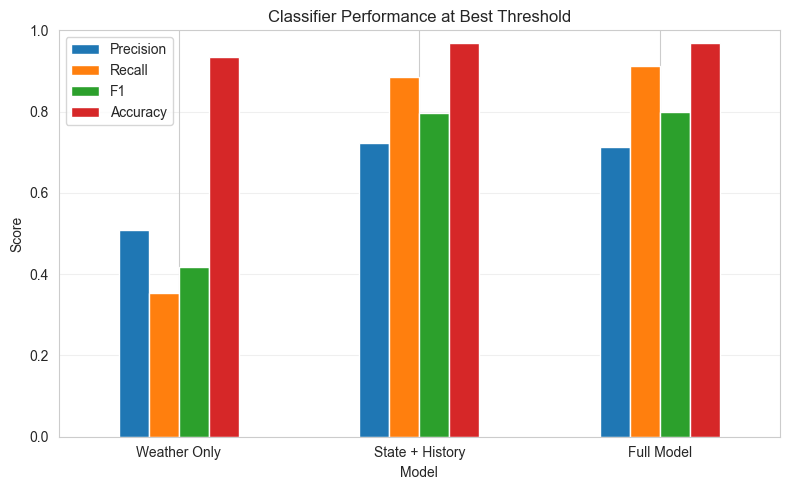

In [15]:

# -----------------------------
# Shared comparison visuals
# -----------------------------
# 1. AUC / AP comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(comparison_display["Model"], comparison_display["Top-N AUC"])
ax[0].set_title("Top-N ROC AUC by Model")
ax[0].set_ylim(0.5, 1.0)
ax[0].grid(axis="y", alpha=0.3)

ax[1].bar(comparison_display["Model"], comparison_display["Top-N AP"])
ax[1].set_title("Top-N Average Precision by Model")
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Precision-recall curves
plt.figure(figsize=(7, 5))
for r in all_results:
    plt.plot(r["recall_curve"], r["precision_curve"], label=r["model_name"])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Top-N Models)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Probability histograms by model
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, r in zip(axes, all_results):
    probs = r["top_probs"]
    ax.hist(probs[y_test_cls == 0], bins=40, alpha=0.6, label="No Event")
    ax.hist(probs[y_test_cls == 1], bins=40, alpha=0.6, label="Event")
    ax.set_title(r["model_name"])
    ax.set_xlabel("Predicted probability")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Count")
axes[0].legend()
plt.suptitle("Predicted Probabilities on Test Set")
plt.tight_layout()
plt.show()

# 4. Lift curves
plt.figure(figsize=(7, 5))
for r in all_results:
    temp = pd.DataFrame({
        "actual_event": y_test_cls.values,
        "prob": r["top_probs"]
    }).sort_values("prob", ascending=False).reset_index(drop=True)
    temp["cum_events"] = temp["actual_event"].cumsum()
    temp["cum_capture"] = temp["cum_events"] / temp["actual_event"].sum()
    temp["pct_rows"] = (np.arange(len(temp)) + 1) / len(temp)
    plt.plot(temp["pct_rows"], temp["cum_capture"], label=r["model_name"])
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")
plt.xlabel("Fraction of test rows reviewed")
plt.ylabel("Fraction of events captured")
plt.title("Lift / Event Capture Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Precision / Recall / F1 bars
metrics_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "Accuracy": r["accuracy"]
    }
    for r in all_results
])
metrics_df.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Classifier Performance at Best Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Weather Only


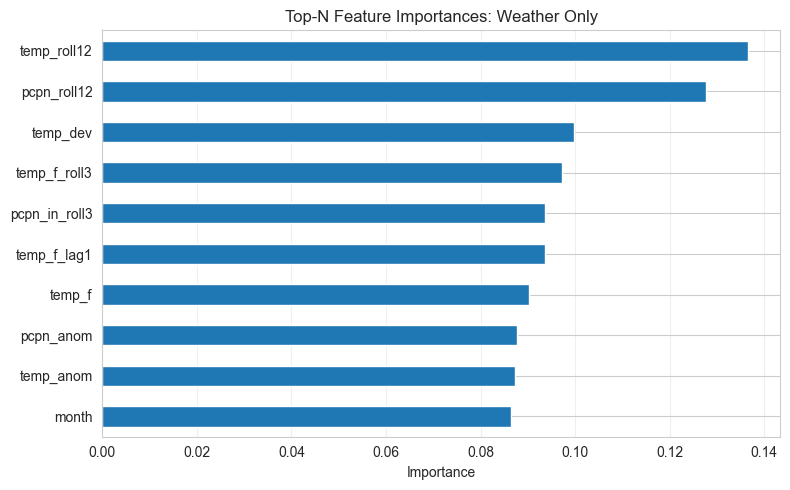

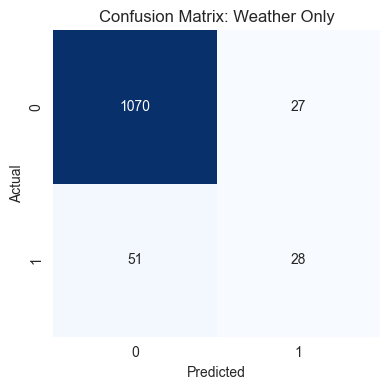

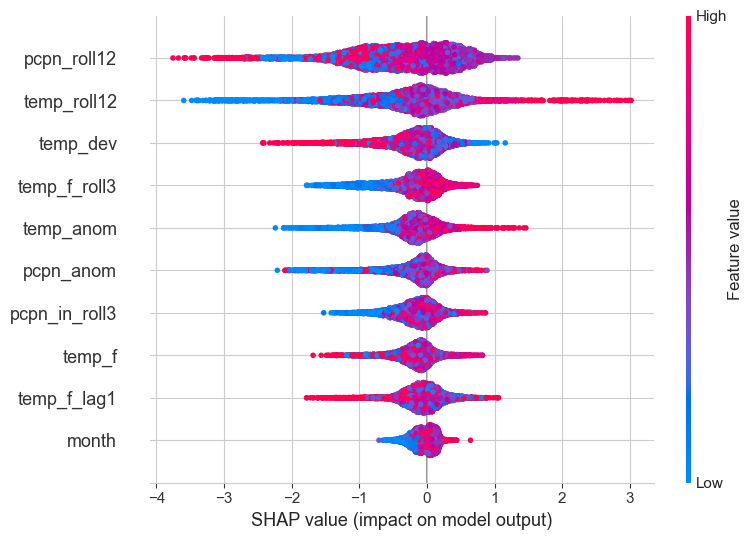


State + History


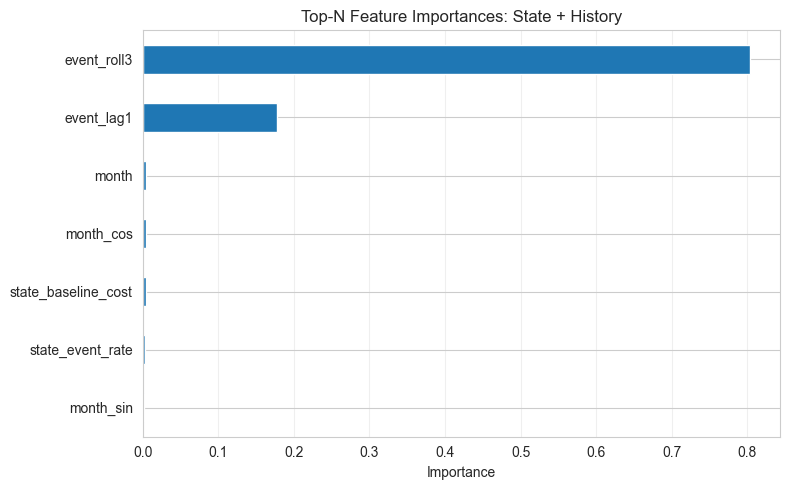

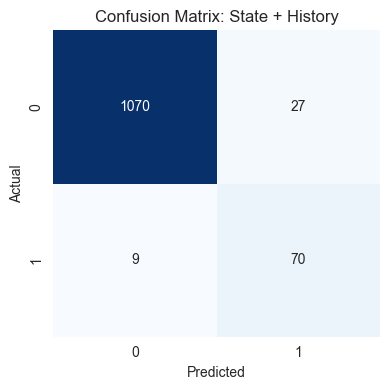

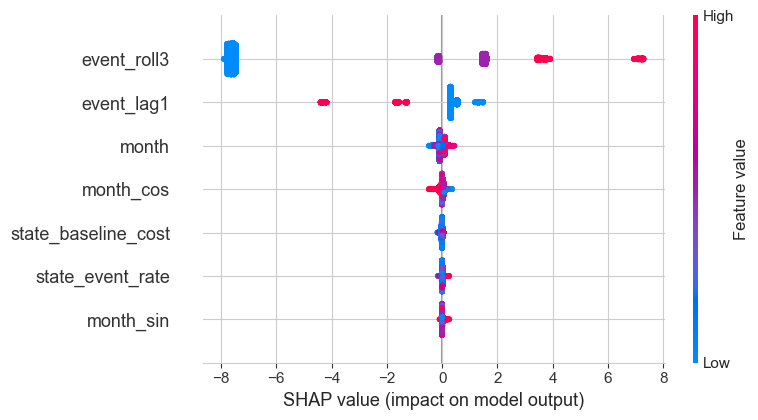


Full Model


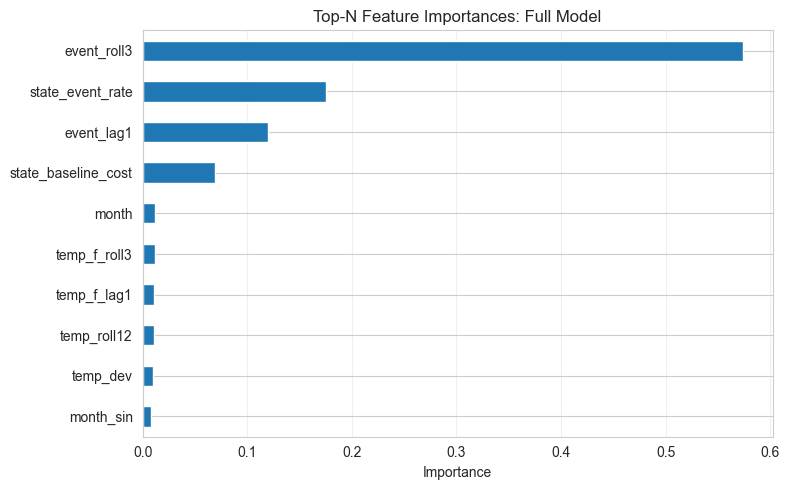

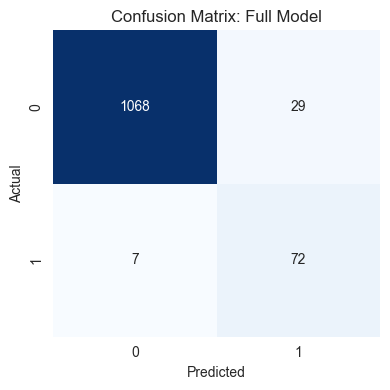

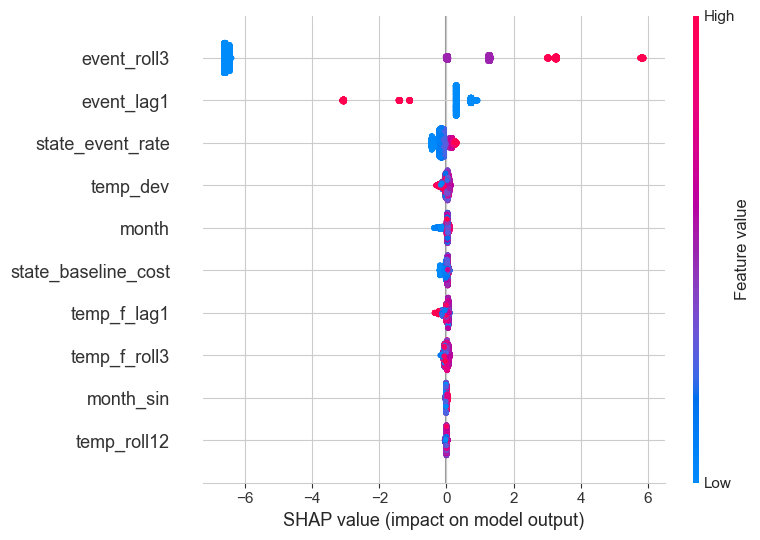

In [7]:

# -----------------------------
# Per-model visuals
# -----------------------------
for r in all_results:
    print("\n" + "="*70)
    print(r["model_name"])

    # Feature importances
    plt.figure(figsize=(8, 5))
    r["feature_importances_top"].sort_values().plot(kind="barh")
    plt.title(f"Top-N Feature Importances: {r['model_name']}")
    plt.xlabel("Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Confusion matrix at best threshold
    cm = r["confusion_matrix"]
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {r['model_name']}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # SHAP summary
    explainer = shap.TreeExplainer(r["clf_top"])
    shap_values = explainer.shap_values(r["X_train_top"])
    shap.summary_plot(shap_values, r["X_train_top"], feature_names=r["top_features"])
